<a href="https://colab.research.google.com/github/MOHAMMAD-Ghouse/Machine-Learning-on-Big-Data-Portfolio/blob/main/Week_3_Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark -q

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler, Imputer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

spark = (
    SparkSession.builder
    .appName("DiabetesPrediction")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Spark Version: 4.0.4


In [2]:
DATA_PATH = "/content/diabetes.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

df.show(5)

Total Rows: 768
Total Columns: 9
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|      1|
|          1|     85|           66|           29|      0|26.6|                   0.351| 31|      0|
|          8|    183|           64|            0|      0|23.3|                   0.672| 32|      1|
|          1|     89|           66|           23|     94|28.1|                   0.167| 21|      0|
|          0|    137|           40|           35|    168|43.1|                   2.288| 33|      1|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
only showing top 5 rows


In [3]:
print("Dataset Schema:")
df.printSchema()

print("\nStatistical Summary:")
df.describe().show()

print("\nDiabetes Outcome Distribution:")
df.groupBy("Outcome").count().show()

Dataset Schema:
root
 |-- Pregnancies: integer (nullable = true)
 |-- Glucose: integer (nullable = true)
 |-- BloodPressure: integer (nullable = true)
 |-- SkinThickness: integer (nullable = true)
 |-- Insulin: integer (nullable = true)
 |-- BMI: double (nullable = true)
 |-- DiabetesPedigreeFunction: double (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Outcome: integer (nullable = true)


Statistical Summary:
+-------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------------+------------------+------------------+
|summary|       Pregnancies|          Glucose|     BloodPressure|     SkinThickness|           Insulin|               BMI|DiabetesPedigreeFunction|               Age|           Outcome|
+-------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------------+------------------+------------------+
|  count|      

In [4]:
# Columns where zero can represent missing/invalid values
health_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace zero values with null
for col_name in health_columns:
    df = df.withColumn(
        col_name,
        F.when(F.col(col_name) == 0, None)
         .otherwise(F.col(col_name))
    )

# Fill missing values using median
imputer = Imputer(
    inputCols=health_columns,
    outputCols=[col + "_clean" for col in health_columns],
    strategy="median"
)

df_clean = imputer.fit(df).transform(df)

print("Rows after preprocessing:", df_clean.count())
df_clean.show(5)

Rows after preprocessing: 768
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+-------------+-------------------+-------------------+-------------+---------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|Glucose_clean|BloodPressure_clean|SkinThickness_clean|Insulin_clean|BMI_clean|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+-------------+-------------------+-------------------+-------------+---------+
|          6|    148|           72|           35|   NULL|33.6|                   0.627| 50|      1|          148|                 72|                 35|          125|     33.6|
|          1|     85|           66|           29|   NULL|26.6|                   0.351| 31|      0|           85|                 66|                 29|          125|     26.6|
|          8|    183|           64|         NULL|   NULL|23.3|                  

In [5]:
feature_columns = [
    "Pregnancies",
    "Glucose_clean",
    "BloodPressure_clean",
    "SkinThickness_clean",
    "Insulin_clean",
    "BMI_clean",
    "DiabetesPedigreeFunction",
    "Age"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

data = assembler.transform(df_clean)

data.select(
    "features",
    "Outcome"
).show(5, truncate=False)

+-------------------------------------------+-------+
|features                                   |Outcome|
+-------------------------------------------+-------+
|[6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0]|1      |
|[1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0] |0      |
|[8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0]|1      |
|[1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0]  |0      |
|[0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0]|1      |
+-------------------------------------------+-------+
only showing top 5 rows


In [6]:
train_data, test_data = data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Records:", train_data.count())
print("Testing Records:", test_data.count())

lr = LogisticRegression(
    featuresCol="features",
    labelCol="Outcome"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)

lr_predictions.select(
    "Outcome",
    "prediction",
    "probability"
).show(10, truncate=False)

Training Records: 645
Testing Records: 123
+-------+----------+-----------------------------------------+
|Outcome|prediction|probability                              |
+-------+----------+-----------------------------------------+
|0      |0.0       |[0.9880220718732425,0.011977928126757464]|
|0      |0.0       |[0.9282067056587517,0.07179329434124826] |
|0      |0.0       |[0.8798046629552649,0.12019533704473506] |
|0      |0.0       |[0.9340297346605528,0.06597026533944716] |
|0      |0.0       |[0.959350055940876,0.04064994405912403]  |
|0      |0.0       |[0.963561272314532,0.036438727685467964] |
|0      |0.0       |[0.8915942419629299,0.10840575803707009] |
|0      |0.0       |[0.8194161061930908,0.1805838938069092]  |
|0      |0.0       |[0.9037443144021557,0.09625568559784425] |
|1      |0.0       |[0.8711680039838233,0.12883199601617668] |
+-------+----------+-----------------------------------------+
only showing top 10 rows


In [7]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="Outcome",
    numTrees=100,
    seed=42
)

rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)

evaluator = BinaryClassificationEvaluator(
    labelCol="Outcome",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

lr_auc = evaluator.evaluate(lr_predictions)
rf_auc = evaluator.evaluate(rf_predictions)

print("Logistic Regression AUC:", round(lr_auc, 4))
print("Random Forest AUC:", round(rf_auc, 4))

# Create comparison table
results = [
    ("Logistic Regression", float(lr_auc)),
    ("Random Forest", float(rf_auc))
]

results_df = spark.createDataFrame(
    results,
    ["Model", "AUC Score"]
)

results_df.show()

Logistic Regression AUC: 0.8637
Random Forest AUC: 0.8544
+-------------------+------------------+
|              Model|         AUC Score|
+-------------------+------------------+
|Logistic Regression|0.8636627906976743|
|      Random Forest|0.8543604651162792|
+-------------------+------------------+



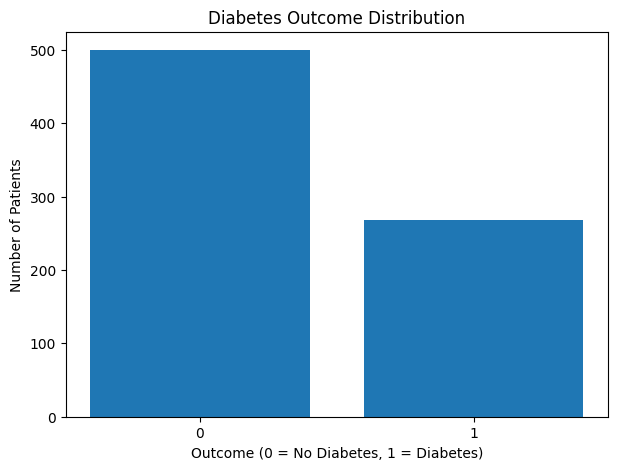


DIABETES PREDICTION USING PYSPARK

Dataset Analysis Completed Successfully

DATA PROCESSING:
• Spark DataFrames
• Data exploration
• Zero value handling
• Median imputation
• Feature vector creation

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

EVALUATION:
• Train/Test Split
• ROC-AUC Score
• Model Comparison

CONCLUSION:
The diabetes dataset was successfully processed using
PySpark. Missing health measurements represented by
zero values were handled using median imputation.
Two classification models were trained and compared
to predict diabetes outcomes.

PROJECT COMPLETE



In [8]:
# Convert outcome counts for plotting
plot_data = (
    df_clean.groupBy("Outcome")
    .count()
    .orderBy("Outcome")
    .toPandas()
)

plt.figure(figsize=(7, 5))

plt.bar(
    plot_data["Outcome"].astype(str),
    plot_data["count"]
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

print("""
====================================================
DIABETES PREDICTION USING PYSPARK
====================================================

Dataset Analysis Completed Successfully

DATA PROCESSING:
• Spark DataFrames
• Data exploration
• Zero value handling
• Median imputation
• Feature vector creation

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

EVALUATION:
• Train/Test Split
• ROC-AUC Score
• Model Comparison

CONCLUSION:
The diabetes dataset was successfully processed using
PySpark. Missing health measurements represented by
zero values were handled using median imputation.
Two classification models were trained and compared
to predict diabetes outcomes.

====================================================
PROJECT COMPLETE
====================================================
""")